In [ ]:
from google.colab import drive, files
drive.mount('/content/gdrive/')

import os
PROJECT_FOLDER = "/content/gdrive/MyDrive/Colab Notebooks/Thesis/Sentiment Analysis"
os.chdir(PROJECT_FOLDER)
print("Current dir: ", os.getcwd())

Mounted at /content/gdrive/
Current dir:  /content/gdrive/MyDrive/Colab Notebooks/Thesis/Sentiment Analysis


In [ ]:
import pandas as pd
data = pd.read_csv("AMZN_VADER_SCORE_READY_FOR_TRAINING.csv")
data.head()

,Unnamed: 0,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,article-title,neg,neu,pos,compound
0,0,2021-05-10,164.115997,164.149994,159.500000,159.524506,116772000,0.0,0.0,"""'Formula One great to develop electric vans, ...",0.000,0.923,0.077,0.8850
1,1,2021-05-11,156.813995,161.899994,156.368500,161.195496,92396000,0.0,0.0,"""'Washington Post names Sally Buzbee first wom...",0.067,0.889,0.044,-0.7430
2,2,2021-05-12,159.250000,160.397003,156.654999,157.597000,98728000,0.0,0.0,"""'Sonos boosts sales outlook despite global ch...",0.065,0.829,0.106,0.8449
3,3,2021-05-13,159.273499,160.192001,156.649994,158.073502,67018000,0.0,0.0,"""'Amazon seeks renewable power for Japan data ...",0.017,0.855,0.128,0.9501
4,4,2021-05-14,159.278000,161.442993,159.149994,161.145004,66500000,0.0,0.0,"""'Less than 3% of U.S. small businesses could ...",0.014,0.914,0.072,0.9008


In [ ]:
days = 60

In [ ]:
data['Close_Difference'] = ""
for i in range(len(data['Close'])):
  try:
    data['Close_Difference'].iloc[i] = data['Close'].iloc[i] - data['Close'].iloc[i-1]
  except IndexError:
    continue

<ipython-input-4-e06bb1f75975>:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['Close_Difference'].iloc[i] = data['Close'].iloc[i] - data['Close'].iloc[i-1]
<ipython-input-4-e06bb1f75975>:4: SettingWithCopyWarning: 
A value is trying t

In [ ]:
data['Close_Difference'].iloc[0] = -5.05549

<ipython-input-5-5eb72f0dcdf3>:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['Close_Difference'].iloc[0] = -5.05549
<ipython-input-5-5eb72f0dcdf3>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

In [ ]:
data.head()

,Unnamed: 0,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,article-title,neg,neu,pos,compound,Close_Difference
0,0,2021-05-10,164.115997,164.149994,159.500000,159.524506,116772000,0.0,0.0,"""'Formula One great to develop electric vans, ...",0.000,0.923,0.077,0.8850,-5.05549
1,1,2021-05-11,156.813995,161.899994,156.368500,161.195496,92396000,0.0,0.0,"""'Washington Post names Sally Buzbee first wom...",0.067,0.889,0.044,-0.7430,1.67099
2,2,2021-05-12,159.250000,160.397003,156.654999,157.597000,98728000,0.0,0.0,"""'Sonos boosts sales outlook despite global ch...",0.065,0.829,0.106,0.8449,-3.598495
3,3,2021-05-13,159.273499,160.192001,156.649994,158.073502,67018000,0.0,0.0,"""'Amazon seeks renewable power for Japan data ...",0.017,0.855,0.128,0.9501,0.476501
4,4,2021-05-14,159.278000,161.442993,159.149994,161.145004,66500000,0.0,0.0,"""'Less than 3% of U.S. small businesses could ...",0.014,0.914,0.072,0.9008,3.071503


In [ ]:
amzn_data = data[['Close_Difference']]
amzn_data.head()

,Close_Difference
0,-5.05549
1,1.67099
2,-3.598495
3,0.476501
4,3.071503


In [ ]:
amzn_data_array = amzn_data.values
print(amzn_data_array)

[[-5.05549]
 [np.float64(1.670989990234375)]
 [np.float64(-3.5984954833984375)]
 [np.float64(0.47650146484375)]
 [np.float64(3.071502685546875)]
 [np.float64(2.3744964599609375)]
 [np.float64(-1.9055023193359375)]
 [np.float64(-0.0240020751953125)]
 [np.float64(0.79400634765625)]
 [np.float64(-2.2299957275390625)]
 [np.float64(2.095489501953125)]
 [np.float64(0.7030029296875)]
 [np.float64(0.3054962158203125)]
 [np.float64(-1.75250244140625)]
 [np.float64(-0.35198974609375)]
 [np.float64(-0.22100830078125)]
 [np.float64(0.766998291015625)]
 [np.float64(-2.3489990234375)]
 [np.float64(0.96051025390625)]
 [np.float64(-0.4105072021484375)]
 [np.float64(3.3050079345703125)]
 [np.float64(0.85198974609375)]
 [np.float64(3.4250030517578125)]
 [np.float64(-0.1409912109375)]
 [np.float64(1.85198974609375)]
 [np.float64(-0.0370025634765625)]
 [np.float64(1.6060028076171875)]
 [np.float64(3.6995086669921875)]
 [np.float64(-0.11700439453125)]
 [np.float64(-1.647003173828125)]
 [np.float64(2.574005

In [ ]:
amzn_comp_len = int(len(amzn_data_array) *0.8)
print(amzn_comp_len)

785


In [ ]:
training_data = amzn_data_array[0:amzn_comp_len]
print(training_data)
print('\n')
print("\n")
print(type(training_data))

[[-5.05549]
 [np.float64(1.670989990234375)]
 [np.float64(-3.5984954833984375)]
 [np.float64(0.47650146484375)]
 [np.float64(3.071502685546875)]
 [np.float64(2.3744964599609375)]
 [np.float64(-1.9055023193359375)]
 [np.float64(-0.0240020751953125)]
 [np.float64(0.79400634765625)]
 [np.float64(-2.2299957275390625)]
 [np.float64(2.095489501953125)]
 [np.float64(0.7030029296875)]
 [np.float64(0.3054962158203125)]
 [np.float64(-1.75250244140625)]
 [np.float64(-0.35198974609375)]
 [np.float64(-0.22100830078125)]
 [np.float64(0.766998291015625)]
 [np.float64(-2.3489990234375)]
 [np.float64(0.96051025390625)]
 [np.float64(-0.4105072021484375)]
 [np.float64(3.3050079345703125)]
 [np.float64(0.85198974609375)]
 [np.float64(3.4250030517578125)]
 [np.float64(-0.1409912109375)]
 [np.float64(1.85198974609375)]
 [np.float64(-0.0370025634765625)]
 [np.float64(1.6060028076171875)]
 [np.float64(3.6995086669921875)]
 [np.float64(-0.11700439453125)]
 [np.float64(-1.647003173828125)]
 [np.float64(2.574005

In [ ]:
from sklearn.preprocessing import MinMaxScaler
x_scaler = MinMaxScaler(feature_range=(-1,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[-2.19642010e-01]
 [ 1.24344408e-01]
 [-1.45132560e-01]
 [ 6.32592893e-02]
 [ 1.95965426e-01]
 [ 1.60321126e-01]
 [-5.85543415e-02]
 [ 3.76639675e-02]
 [ 7.94962167e-02]
 [-7.51486561e-02]
 [ 1.46052949e-01]
 [ 7.48423800e-02]
 [ 5.45142275e-02]
 [-5.07300589e-02]
 [ 2.08909593e-02]
 [ 2.75892380e-02]
 [ 7.81150479e-02]
 [-8.12343826e-02]
 [ 8.80110837e-02]
 [ 1.78984267e-02]
 [ 2.07906684e-01]
 [ 8.24614380e-02]
 [ 2.14043132e-01]
 [ 3.16812434e-02]
 [ 1.33600580e-01]
 [ 3.69991336e-02]
 [ 1.21021019e-01]
 [ 2.28081114e-01]
 [ 3.29079086e-02]
 [-4.53349169e-02]
 [ 1.70523828e-01]
 [ 3.47486868e-02]
 [-1.01076395e-01]
 [-8.28707165e-02]
 [ 1.47383397e-01]
 [ 4.97581686e-02]
 [ 1.84867891e-02]
 [ 2.05070411e-02]
 [ 2.38359507e-01]
 [ 4.60176005e-01]
 [ 9.21779999e-02]
 [ 1.27950273e-01]
 [ 8.02892183e-03]
 [ 3.68719413e-02]
 [-6.64301252e-02]
 [ 4.99376426e-02]
 [-9.01838886e-02]
 [-1.08312315e-01]
 [-2.25776239e-02]
 [ 9.92352265e-02]
 [ 6.96001809e-02]
 [ 1.73975970e-01]
 [ 8.6476191

In [ ]:
test = amzn_data[amzn_comp_len :]
print(test.shape)

(197, 1)


In [ ]:
test_inputs = amzn_data_array[len(amzn_data_array) - len(test) -days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 1)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (257, 1)
Test inputs with a reshape : (257, 1)
Test inputs after transformed : (257, 1)


In [ ]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,0])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {60} day minimum")

print(type(X_train))
print(type(y_train))


These values are smaller than the 60 day minimum
<class 'list'>
<class 'list'>


In [ ]:
import numpy as np
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(725, 60)
(725, 1)


In [ ]:
X_test = []
y_test = amzn_data_array[amzn_comp_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, 0])

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],1))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(725, 60, 1)
725
60


In [ ]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],1))
print(X_test.shape)

(197, 60)
(197, 60, 1)


In [ ]:
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dropout, Activation, Dense
model1 = Sequential()
model1.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 1), activation='tanh'))
model1.add(Dropout(0.2))
model1.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model1.add(Dropout(0.2))
model1.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model1.add(Dropout(0.2))
model1.add(LSTM(units = 100, activation='tanh'))
model1.add(Dropout(0.2))
model1.add(Dense(units=1))
model1.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model1.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,101 (1.08 MB)

 Trainable params: 282,101 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
seed = 412
np.random.seed(seed)
tf.random.set_seed(seed)
history1 = model1.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0281 - mae: 0.1194
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0279 - mae: 0.1181
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0276 - mae: 0.1174
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0277 - mae: 0.1177
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0277 - mae: 0.1175
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0277 - mae: 0.1174
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0279 - mae: 0.1177
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0277 - mae: 0.1175
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0279 - mae: 0.1174
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0277 - mae: 0.1171
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0278 - mae: 0.1173
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0275 - mae: 0.1167
Epoch 13/300
23/23 ━━━━━━

Text(0, 0.5, 'MAE')

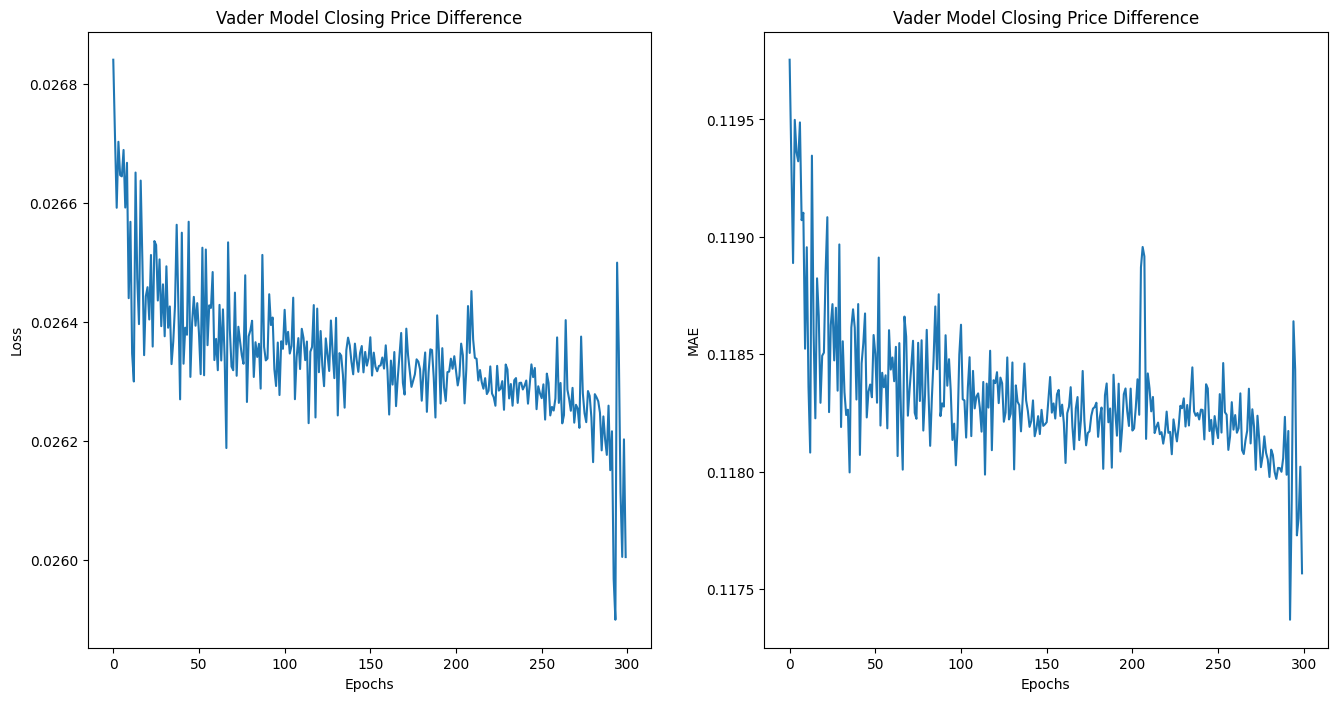

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(history1.history['loss'], label = 'Training Loss')
plt.title("Vader Model Closing Price Difference")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(history1.history['mae'], label = 'Mean Absolute Error')
plt.title("Vader Model Closing Price Difference")
plt.xlabel("Epochs")
plt.ylabel("MAE")

In [ ]:
predictions = model1.predict(X_test)
predictions = x_scaler.inverse_transform(predictions)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


In [ ]:
rmse1 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse1)

0.1302643967851486


In [ ]:
dates = data['Date']

<ipython-input-30-6b849f6d6f84>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Date'] = dates[:amzn_comp_len]
<ipython-input-30-6b849f6d6f84>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing['Date'] = dates[amzn_comp_len:]
<ipython-input-30-6b849f6d6f84>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

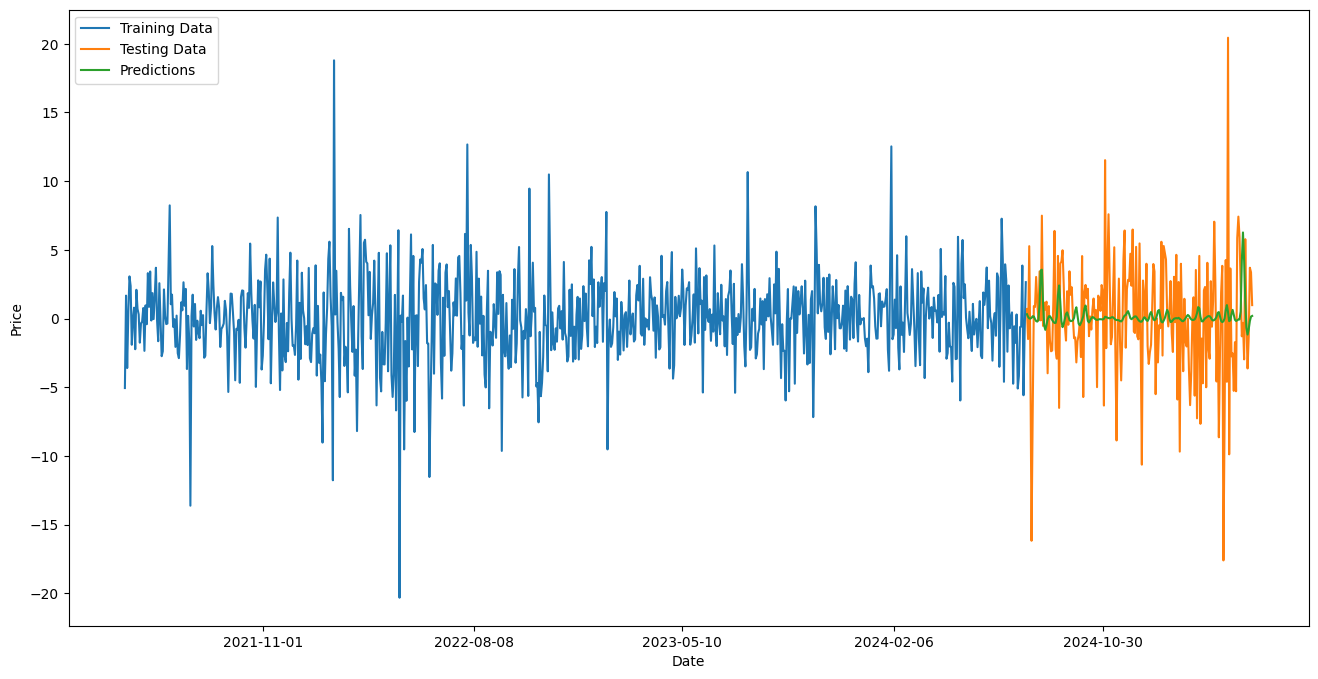

In [ ]:
train = amzn_data[:amzn_comp_len]
train['Date'] = dates[:amzn_comp_len]
testing = amzn_data[amzn_comp_len:]
testing['Date'] = dates[amzn_comp_len:]
testing['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train['Date'],train['Close_Difference'], label = "Training Data")
plt.plot(testing['Date'],testing['Close_Difference'], label = "Testing Data")
plt.plot(testing['Date'], testing['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [ ]:
testing.head()

,Close_Difference,Date,Predictions,Actual
785,0.699997,2024-07-29,1.056043e-02,0.489996
786,-1.48999,2024-07-30,2.324634e-04,2.220071
787,5.269989,2024-07-31,1.848877e-08,27.772784
788,-2.909988,2024-08-01,2.382388e-11,8.468033
789,-16.170013,2024-08-02,9.563046e-06,261.469334


# **Model with both Closing and difference**

In [ ]:
data.head()

,Unnamed: 0,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,article-title,neg,neu,pos,compound,Close_Difference
0,0,2021-05-10,164.115997,164.149994,159.500000,159.524506,116772000,0.0,0.0,"""'Formula One great to develop electric vans, ...",0.000,0.923,0.077,0.8850,-5.05549
1,1,2021-05-11,156.813995,161.899994,156.368500,161.195496,92396000,0.0,0.0,"""'Washington Post names Sally Buzbee first wom...",0.067,0.889,0.044,-0.7430,1.67099
2,2,2021-05-12,159.250000,160.397003,156.654999,157.597000,98728000,0.0,0.0,"""'Sonos boosts sales outlook despite global ch...",0.065,0.829,0.106,0.8449,-3.598495
3,3,2021-05-13,159.273499,160.192001,156.649994,158.073502,67018000,0.0,0.0,"""'Amazon seeks renewable power for Japan data ...",0.017,0.855,0.128,0.9501,0.476501
4,4,2021-05-14,159.278000,161.442993,159.149994,161.145004,66500000,0.0,0.0,"""'Less than 3% of U.S. small businesses could ...",0.014,0.914,0.072,0.9008,3.071503


In [ ]:
days = 60

In [ ]:
amzn_data = data[['Close','Close_Difference']]
amzn_data.head()

,Close,Close_Difference
0,159.524506,-5.05549
1,161.195496,1.67099
2,157.597000,-3.598495
3,158.073502,0.476501
4,161.145004,3.071503


In [ ]:
amzn_data_array = amzn_data.values
print(amzn_data_array)

[[159.52450561523438 -5.05549]
 [161.19549560546875 np.float64(1.670989990234375)]
 [157.5970001220703 np.float64(-3.5984954833984375)]
 ...
 [188.7100067138672 np.float64(3.700012207031193)]
 [192.0800018310547 np.float64(3.3699951171875)]
 [193.0599975585937 np.float64(0.9799957275390057)]]


In [ ]:
amzn_len = int(len(amzn_data_array) *0.8)
print(amzn_len)

785


In [ ]:
training_data = amzn_data_array[0:amzn_len]
print(training_data)
print('\n')
print(type(training_data))

[[159.52450561523438 -5.05549]
 [161.19549560546875 np.float64(1.670989990234375)]
 [157.5970001220703 np.float64(-3.5984954833984375)]
 ...
 [180.8300018310547 np.float64(-5.580001831054602)]
 [179.85000610351562 np.float64(-0.9799957275390625)]
 [182.5 np.float64(2.649993896484375)]]


<class 'numpy.ndarray'>


In [ ]:
x_scaler = MinMaxScaler(feature_range=(-1,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[ 0.31501956 -0.21964201]
 [ 0.34329829  0.12434441]
 [ 0.28239973 -0.14513256]
 ...
 [ 0.67557966 -0.2464651 ]
 [ 0.65899486 -0.01122473]
 [ 0.7038416   0.17440983]]


(785, 2)


In [ ]:
test = amzn_data_array[amzn_len:]
print(test.shape)

(197, 2)


In [ ]:
test_inputs = amzn_data_array[len(amzn_data) - len(test) - days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 2)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (257, 2)
Test inputs with a reshape : (257, 2)
Test inputs after transformed : (257, 2)


In [ ]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))

These values are smaller than the 60 day minimum
<class 'list'>
<class 'list'>


In [ ]:
import numpy as np
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(725, 60, 2)
(725, 1)


In [ ]:
X_test = []
y_test = amzn_data_array[amzn_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],2))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(725, 60, 2)
725
60


In [ ]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],2))
print(X_test.shape)

(197, 60, 2)
(197, 60, 2)


In [ ]:
model2 = Sequential()
model2.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 2), activation='tanh'))
model2.add(Dropout(0.2))
model2.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model2.add(Dropout(0.2))
model2.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model2.add(Dropout(0.2))
model2.add(LSTM(units = 100, activation='tanh'))
model2.add(Dropout(0.2))
model2.add(Dense(units=1))
model2.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model2.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 100)        │        41,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,501 (1.08 MB)

 Trainable params: 282,501 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history2 = model2.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.1185 - mae: 0.2679
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0256 - mae: 0.1280
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0194 - mae: 0.1113
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0157 - mae: 0.0974
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0146 - mae: 0.0942
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0130 - mae: 0.0890
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0124 - mae: 0.0854
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0109 - mae: 0.0813
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0100 - mae: 0.0757
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0088 - mae: 0.0737
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0092 - mae: 0.0753
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0083 - mae: 0.0704
Epoch 13/300
23/23 ━━━━━━

Text(0, 0.5, 'MAE')

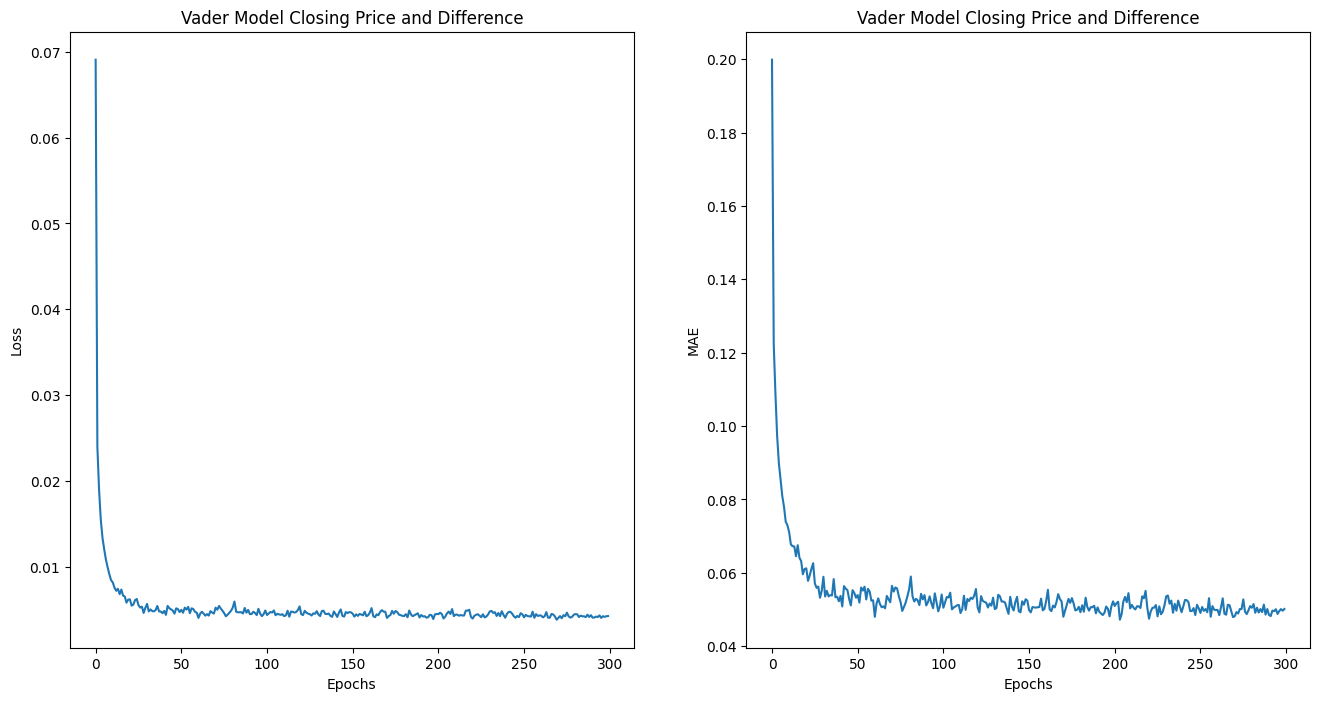

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(history2.history['loss'], label = 'Training Loss')
plt.title("Vader Model Closing Price and Difference")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(history2.history['mae'], label = 'Mean Absolute Error')
plt.title("Vader Model Closing Price and Difference")
plt.xlabel("Epochs")
plt.ylabel("MAE")

In [ ]:
predictions = model2.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 1))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
predictions = predictions_inverted[:, 0]

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


In [ ]:
rmse2 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse2)

3.8349061613872104


<ipython-input-54-28002db58798>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['Date'] = dates[:amzn_comp_len]
<ipython-input-54-28002db58798>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing2['Date'] = dates[amzn_comp_len:]
<ipython-input-54-28002db58798>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

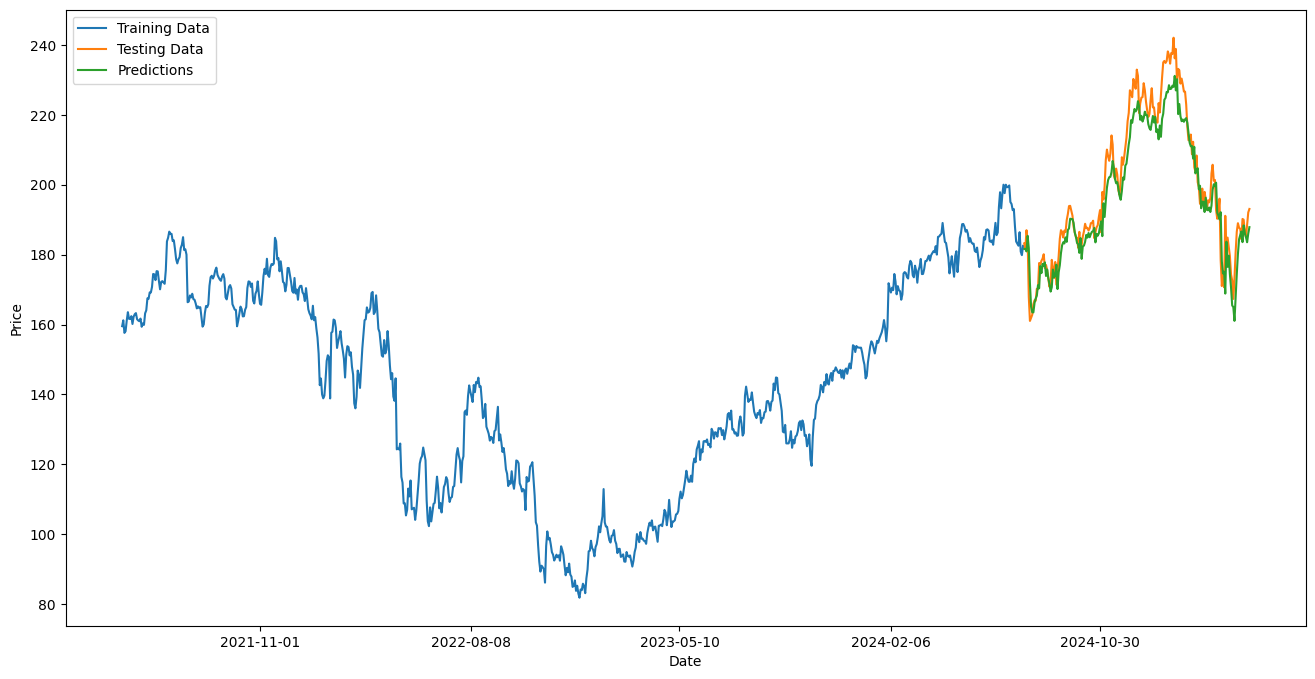

In [ ]:
train2 = amzn_data[:amzn_comp_len]
train2['Date'] = dates[:amzn_comp_len]
testing2 = amzn_data[amzn_comp_len:]
testing2['Date'] = dates[amzn_comp_len:]
testing2['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train2['Date'],train2['Close'], label = "Training Data")
plt.plot(testing2['Date'],testing2['Close'], label = "Testing Data")
plt.plot(testing2['Date'], testing2['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [ ]:
testing2.head(10)

,Close,Close_Difference,Date,Predictions
785,183.199997,0.699997,2024-07-29,181.646425
786,181.710007,-1.48999,2024-07-30,181.629051
787,186.979996,5.269989,2024-07-31,180.912320
788,184.070007,-2.909988,2024-08-01,185.373267
789,167.899994,-16.170013,2024-08-02,181.891982
790,161.020004,-6.87999,2024-08-05,171.683008
791,161.929993,0.909988,2024-08-06,165.067192
792,162.770004,0.840012,2024-08-07,163.504497
793,165.800003,3.029999,2024-08-08,163.464377
794,166.940002,1.139999,2024-08-09,166.153922


# **Closing Difference Model 2**

In [ ]:
data.head()

,Unnamed: 0,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,article-title,neg,neu,pos,compound,Close_Difference
0,0,2021-05-10,164.115997,164.149994,159.500000,159.524506,116772000,0.0,0.0,"""'Formula One great to develop electric vans, ...",0.000,0.923,0.077,0.8850,-5.05549
1,1,2021-05-11,156.813995,161.899994,156.368500,161.195496,92396000,0.0,0.0,"""'Washington Post names Sally Buzbee first wom...",0.067,0.889,0.044,-0.7430,1.67099
2,2,2021-05-12,159.250000,160.397003,156.654999,157.597000,98728000,0.0,0.0,"""'Sonos boosts sales outlook despite global ch...",0.065,0.829,0.106,0.8449,-3.598495
3,3,2021-05-13,159.273499,160.192001,156.649994,158.073502,67018000,0.0,0.0,"""'Amazon seeks renewable power for Japan data ...",0.017,0.855,0.128,0.9501,0.476501
4,4,2021-05-14,159.278000,161.442993,159.149994,161.145004,66500000,0.0,0.0,"""'Less than 3% of U.S. small businesses could ...",0.014,0.914,0.072,0.9008,3.071503


In [ ]:
close_data = data[['Close_Difference','Close','neg','pos']]
close_data.head()

,Close_Difference,Close,neg,pos
0,-5.05549,159.524506,0.000,0.077
1,1.67099,161.195496,0.067,0.044
2,-3.598495,157.597000,0.065,0.106
3,0.476501,158.073502,0.017,0.128
4,3.071503,161.145004,0.014,0.072


In [ ]:
close_data_array = close_data.values
print(close_data_array)

[[-5.05549 159.52450561523438 0.0 0.077]
 [np.float64(1.670989990234375) 161.19549560546875 0.067 0.044]
 [np.float64(-3.5984954833984375) 157.5970001220703 0.065 0.106]
 ...
 [np.float64(3.700012207031193) 188.7100067138672 0.036 0.033]
 [np.float64(3.3699951171875) 192.0800018310547 0.02 0.078]
 [np.float64(0.9799957275390057) 193.0599975585937 0.081 0.035]]


In [ ]:
close_data_len = int(len(close_data_array) *0.8)
print(close_data_len)

785


In [ ]:
training_data = close_data_array[0:close_data_len]
print(training_data)
print('\n')
print(type(training_data))

[[-5.05549 159.52450561523438 0.0 0.077]
 [np.float64(1.670989990234375) 161.19549560546875 0.067 0.044]
 [np.float64(-3.5984954833984375) 157.5970001220703 0.065 0.106]
 ...
 [np.float64(-5.580001831054602) 180.8300018310547 0.037 0.072]
 [np.float64(-0.9799957275390625) 179.85000610351562 0.039 0.06]
 [np.float64(2.649993896484375) 182.5 0.007 0.057]]


<class 'numpy.ndarray'>


In [ ]:
x_scaler = MinMaxScaler(feature_range=(-1,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[-0.21964201  0.31501956 -1.         -0.60512821]
 [ 0.12434441  0.34329829 -0.47859922 -0.77435897]
 [-0.14513256  0.28239973 -0.49416342 -0.45641026]
 ...
 [-0.2464651   0.67557966 -0.71206226 -0.63076923]
 [-0.01122473  0.65899486 -0.69649805 -0.69230769]
 [ 0.17440983  0.7038416  -0.94552529 -0.70769231]]


(785, 4)


In [ ]:
test = close_data_array[close_data_len:]
print(test.shape)

(197, 4)


In [ ]:
test_inputs = close_data_array[len(close_data) - len(test) - days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 4)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (257, 4)
Test inputs with a reshape : (257, 4)
Test inputs after transformed : (257, 4)


In [ ]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))

These values are smaller than the 60 day minimum
<class 'list'>
<class 'list'>


In [ ]:
import numpy as np
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(725, 60, 4)
(725, 1)


In [ ]:
X_test = []
y_test = close_data_array[amzn_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])
y_test

array([np.float64(0.6999969482421875), np.float64(-1.489990234375),
       np.float64(5.269989013671847), np.float64(-2.909988403320284),
       np.float64(-16.170013427734375), np.float64(-6.8799896240234375),
       np.float64(0.9099884033203125), np.float64(0.8400115966796875),
       np.float64(3.029998779296875), np.float64(1.1399993896484375),
       np.float64(-0.1399993896484375), np.float64(3.42999267578125),
       np.float64(-0.1299896240234375), np.float64(7.489990234375),
       np.float64(-0.529998779296875), np.float64(1.160003662109375),
       np.float64(0.660003662109375), np.float64(1.2299957275390625),
       np.float64(-3.9799957275390625), np.float64(0.9099884033203125),
       np.float64(-1.5399932861328125), np.float64(-2.3800048828125),
       np.float64(-2.3199920654296875), np.float64(1.3199920654296875),
       np.float64(6.3800048828125), np.float64(-2.25),
       np.float64(-2.9199981689453125), np.float64(4.55999755859375),
       np.float64(-6.5), np.flo

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],4))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(725, 60, 4)
725
60


In [ ]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],4))
print(X_test.shape)

(197, 60, 4)
(197, 60, 4)


In [ ]:
model3 = Sequential()
model3.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 4), activation='tanh'))
model3.add(Dropout(0.2))
model3.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model3.add(Dropout(0.2))
model3.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model3.add(Dropout(0.2))
model3.add(LSTM(units = 100, activation='tanh'))
model3.add(Dropout(0.2))
model3.add(Dense(units=1))
model3.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model3.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 60, 100)        │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_26 (LSTM)                  │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_27 (LSTM)                  │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,301 (1.08 MB)

 Trainable params: 283,301 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
np.random.seed(seed)
tf.random.set_seed(seed)
history3 = model3.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0286 - mae: 0.1239
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0289 - mae: 0.1221
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0275 - mae: 0.1177
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0276 - mae: 0.1173
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0275 - mae: 0.1177
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0280 - mae: 0.1188
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0279 - mae: 0.1182
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0276 - mae: 0.1175
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0277 - mae: 0.1177
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0278 - mae: 0.1187
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0277 - mae: 0.1171
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0279 - mae: 0.1176
Epoch 13/300
23/23 ━━━━━━

Text(0, 0.5, 'MAE')

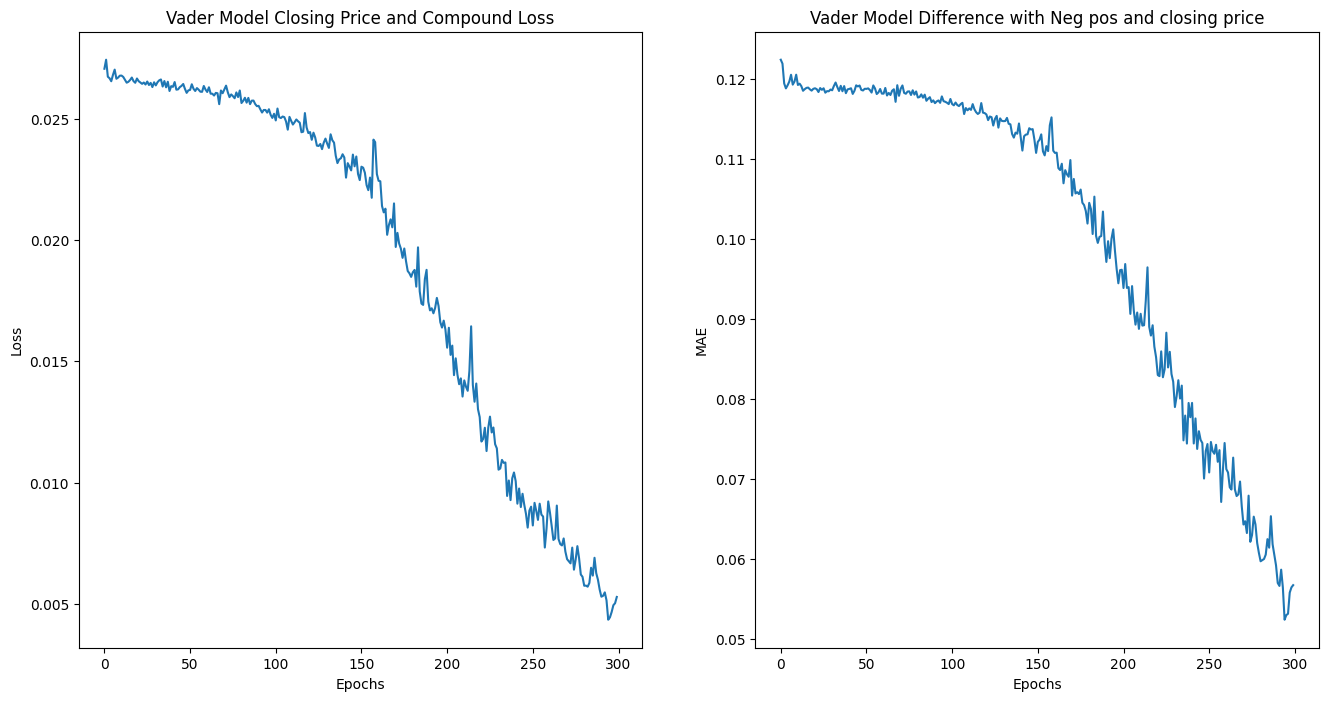

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(history3.history['loss'], label = 'Training Loss')
plt.title("Vader Model Closing Price and Compound Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(history3.history['mae'], label = 'Mean Absolute Error')
plt.title("Vader Model Difference with Neg pos and closing price")
plt.xlabel("Epochs")
plt.ylabel("MAE")

In [ ]:
predictions = model3.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 3))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
print(predictions_inverted)
print(predictions_concat.shape)
print(predictions.shape)
predictions = predictions_inverted[:, 0]
print(predictions)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
[[-9.33619401e+00  1.40910000e+02  1.28500000e-01  1.95000000e-01]
 [-9.30163112e+00  1.40910000e+02  1.28500000e-01  1.95000000e-01]
 [-9.27517631e+00  1.40910000e+02  1.28500000e-01  1.95000000e-01]
 [-9.19110135e+00  1.40910000e+02  1.28500000e-01  1.95000000e-01]
 [-9.17401106e+00  1.40910000e+02  1.28500000e-01  1.95000000e-01]
 [-9.27812454e+00  1.40910000e+02  1.28500000e-01  1.95000000e-01]
 [-9.11092511e+00  1.40910000e+02  1.28500000e-01  1.95000000e-01]
 [-7.84962644e+00  1.40910000e+02  1.28500000e-01  1.95000000e-01]
 [-7.15792998e+00  1.40910000e+02  1.28500000e-01  1.95000000e-01]
 [-7.27114340e+00  1.40910000e+02  1.28500000e-01  1.95000000e-01]
 [-7.72541907e+00  1.40910000e+02  1.28500000e-01  1.95000000e-01]
 [-7.94748448e+00  1.40910000e+02  1.28500000e-01  1.95000000e-01]
 [-8.19769648e+00  1.40910000e+02  1.28500000e-01  1.95000000e-01]
 [-8.37982121e+00  1.40910000e+02  1.28500000e-01  1.95000000e-01]
 [-8.52510327e+00  1.409

In [ ]:
rmse3 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse3)

9.082318816649309


<ipython-input-150-e66444c80952>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train3['Date'] = dates[:amzn_comp_len]
<ipython-input-150-e66444c80952>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing3['Date'] = dates[amzn_comp_len:]
<ipython-input-150-e66444c80952>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

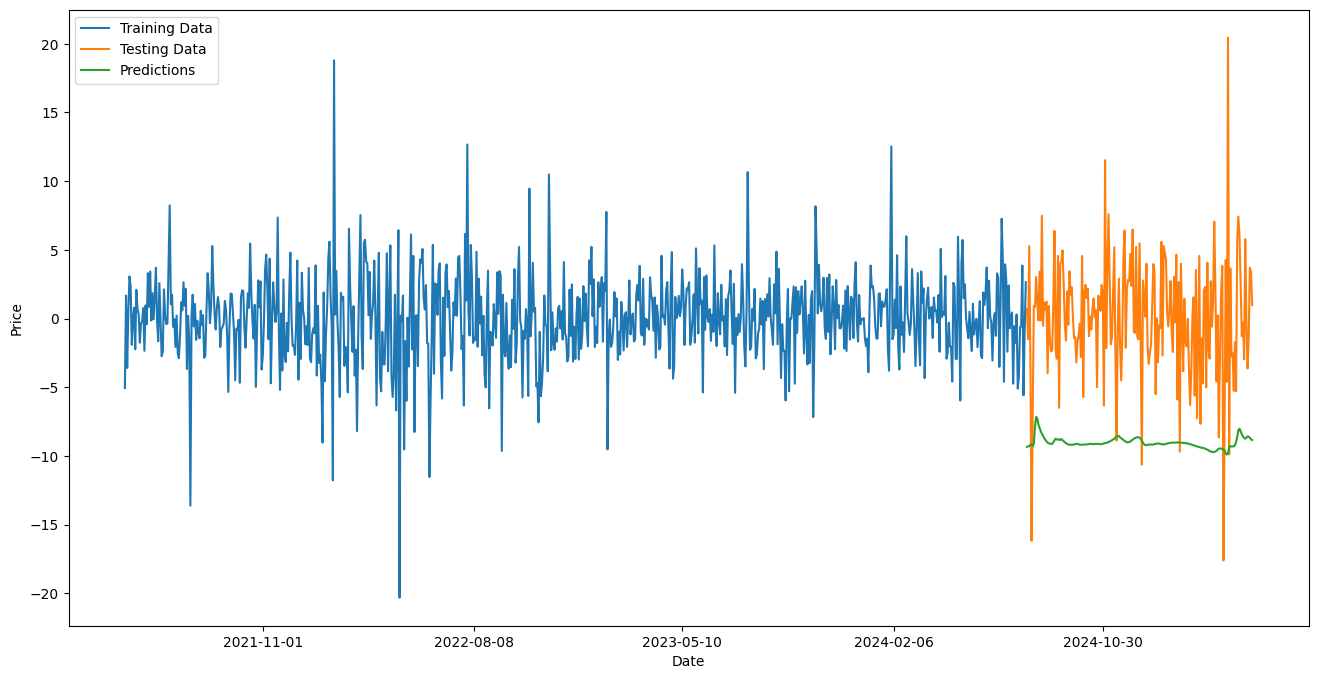

In [ ]:
train3 = close_data[:amzn_comp_len]
train3['Date'] = dates[:amzn_comp_len]
testing3 = close_data[amzn_comp_len:]
testing3['Date'] = dates[amzn_comp_len:]
testing3['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train3['Date'],train3['Close_Difference'], label = "Training Data")
plt.plot(testing3['Date'],testing3['Close_Difference'], label = "Testing Data")
plt.plot(testing3['Date'], testing3['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [ ]:
testing3.head(10)

,Close_Difference,Close,neg,pos,Date,Predictions
785,0.699997,183.199997,0.006,0.046,2024-07-29,-9.336194
786,-1.48999,181.710007,0.049,0.038,2024-07-30,-9.301631
787,5.269989,186.979996,0.043,0.152,2024-07-31,-9.275176
788,-2.909988,184.070007,0.052,0.052,2024-08-01,-9.191101
789,-16.170013,167.899994,0.054,0.072,2024-08-02,-9.174011
790,-6.87999,161.020004,0.155,0.042,2024-08-05,-9.278125
791,0.909988,161.929993,0.038,0.081,2024-08-06,-9.110925
792,0.840012,162.770004,0.000,0.039,2024-08-07,-7.849626
793,3.029999,165.800003,0.012,0.110,2024-08-08,-7.157930
794,1.139999,166.940002,0.037,0.049,2024-08-09,-7.271143


# **Model with Closing, Difference Squared and Compound**

In [ ]:
amzn_data = data[['Close','Close_Difference','compound','neg','pos']]
amzn_data.head()

,Close,Close_Difference,compound,neg,pos
0,159.524506,-5.05549,0.8850,0.000,0.077
1,161.195496,1.67099,-0.7430,0.067,0.044
2,157.597000,-3.598495,0.8449,0.065,0.106
3,158.073502,0.476501,0.9501,0.017,0.128
4,161.145004,3.071503,0.9008,0.014,0.072


In [ ]:
amzn_data_array = amzn_data.values
print(amzn_data_array)

[[159.52450561523438 -5.05549 0.885 0.0 0.077]
 [161.19549560546875 np.float64(1.670989990234375) -0.743 0.067 0.044]
 [157.5970001220703 np.float64(-3.5984954833984375) 0.8449 0.065 0.106]
 ...
 [188.7100067138672 np.float64(3.700012207031193) -0.2732 0.036 0.033]
 [192.0800018310547 np.float64(3.3699951171875) 0.8422 0.02 0.078]
 [193.0599975585937 np.float64(0.9799957275390057) -0.9246 0.081 0.035]]


In [ ]:
amzn_len = int(len(amzn_data_array) *0.8)
print(amzn_len)

785


In [ ]:
training_data = amzn_data_array[0:amzn_len]
print(training_data)
print('\n')
print(type(training_data))

[[159.52450561523438 -5.05549 0.885 0.0 0.077]
 [161.19549560546875 np.float64(1.670989990234375) -0.743 0.067 0.044]
 [157.5970001220703 np.float64(-3.5984954833984375) 0.8449 0.065 0.106]
 ...
 [180.8300018310547 np.float64(-5.580001831054602) 0.7845 0.037 0.072]
 [179.85000610351562 np.float64(-0.9799957275390625) 0.3818 0.039 0.06]
 [182.5 np.float64(2.649993896484375) 0.8885 0.007 0.057]]


<class 'numpy.ndarray'>


In [ ]:
from sklearn.preprocessing import MinMaxScaler
x_scaler = MinMaxScaler(feature_range=(-1,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[ 0.31501956 -0.21964201  0.88567694 -1.         -0.60512821]
 [ 0.34329829  0.12434441 -0.75124428 -0.47859922 -0.77435897]
 [ 0.28239973 -0.14513256  0.8453572  -0.49416342 -0.45641026]
 ...
 [ 0.67557966 -0.2464651   0.78462621 -0.71206226 -0.63076923]
 [ 0.65899486 -0.01122473  0.37971947 -0.69649805 -0.69230769]
 [ 0.7038416   0.17440983  0.88919612 -0.94552529 -0.70769231]]


(785, 5)


In [ ]:
test = amzn_data_array[amzn_len:]
print(test.shape)

(197, 5)


In [ ]:
test_inputs = amzn_data_array[len(amzn_data) - len(test) - days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 5)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (257, 5)
Test inputs with a reshape : (257, 5)
Test inputs after transformed : (257, 5)


In [ ]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))

These values are smaller than the 60 day minimum
<class 'list'>
<class 'list'>


In [ ]:
import numpy as np
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(725, 60, 5)
(725, 1)


In [ ]:
X_test = []
y_test = amzn_data_array[amzn_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],5))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(725, 60, 5)
725
60


In [ ]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],5))
print(X_test.shape)

(197, 60, 5)
(197, 60, 5)


In [ ]:
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dropout, Activation, Dense
model4 = Sequential()
model4.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 5), activation='tanh'))
model4.add(Dropout(0.2))
model4.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model4.add(Dropout(0.2))
model4.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model4.add(Dropout(0.2))
model4.add(LSTM(units = 100, activation='tanh'))
model4.add(Dropout(0.2))
model4.add(Dense(units=1))
model4.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model4.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        42,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,701 (1.08 MB)

 Trainable params: 283,701 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
seed = 412
np.random.seed(seed)
tf.random.set_seed(seed)
history4 = model4.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1188 - mae: 0.2730
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0305 - mae: 0.1370
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0206 - mae: 0.1135
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0174 - mae: 0.1034
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0160 - mae: 0.0978
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0148 - mae: 0.0971
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0128 - mae: 0.0898
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0130 - mae: 0.0894
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0117 - mae: 0.0841
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0095 - mae: 0.0764
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0114 - mae: 0.0823
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0113 - mae: 0.0831
Epoch 13/300
23/23 ━━━━━━

Text(0, 0.5, 'MAE')

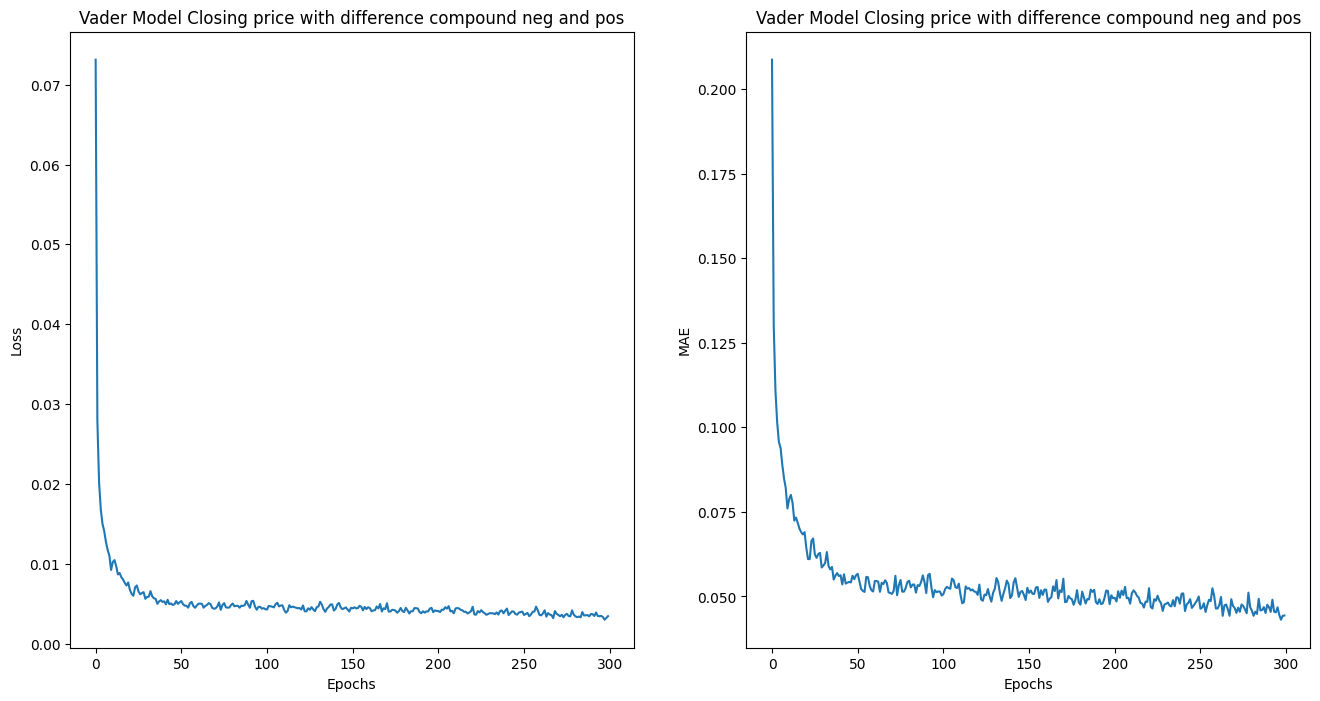

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(history4.history['loss'], label = 'Training Loss')
plt.title("Vader Model Closing price with difference compound neg and pos")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(history4.history['mae'], label = 'Mean Absolute Error')
plt.title("Vader Model Closing price with difference compound neg and pos")
plt.xlabel("Epochs")
plt.ylabel("MAE")

In [ ]:
predictions = model4.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 4))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
print(predictions_inverted)
print(predictions_concat.shape)
print(predictions.shape)
predictions = predictions_inverted[:, 0]
print(predictions)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
[[ 1.78808155e+02 -7.60501862e-01  4.15000000e-03  1.28500000e-01
   1.95000000e-01]
 [ 1.79243092e+02 -7.60501862e-01  4.15000000e-03  1.28500000e-01
   1.95000000e-01]
 [ 1.78199064e+02 -7.60501862e-01  4.15000000e-03  1.28500000e-01
   1.95000000e-01]
 [ 1.82912672e+02 -7.60501862e-01  4.15000000e-03  1.28500000e-01
   1.95000000e-01]
 [ 1.79099562e+02 -7.60501862e-01  4.15000000e-03  1.28500000e-01
   1.95000000e-01]
 [ 1.71167853e+02 -7.60501862e-01  4.15000000e-03  1.28500000e-01
   1.95000000e-01]
 [ 1.62524407e+02 -7.60501862e-01  4.15000000e-03  1.28500000e-01
   1.95000000e-01]
 [ 1.63883445e+02 -7.60501862e-01  4.15000000e-03  1.28500000e-01
   1.95000000e-01]
 [ 1.59513964e+02 -7.60501862e-01  4.15000000e-03  1.28500000e-01
   1.95000000e-01]
 [ 1.60106080e+02 -7.60501862e-01  4.15000000e-03  1.28500000e-01
   1.95000000e-01]
 [ 1.59796058e+02 -7.60501862e-01  4.15000000e-03  1.28500000e-01
   1.95000000e-01]
 [ 1.59924563e+02 -7.605018

In [ ]:
rmse4 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse4)

12.079986953646628


In [ ]:
dates = data['Date']

<ipython-input-29-556d0a53b9bc>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train4['Date'] = dates[:amzn_len]
<ipython-input-29-556d0a53b9bc>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing4['Date'] = dates[amzn_len:]
<ipython-input-29-556d0a53b9bc>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

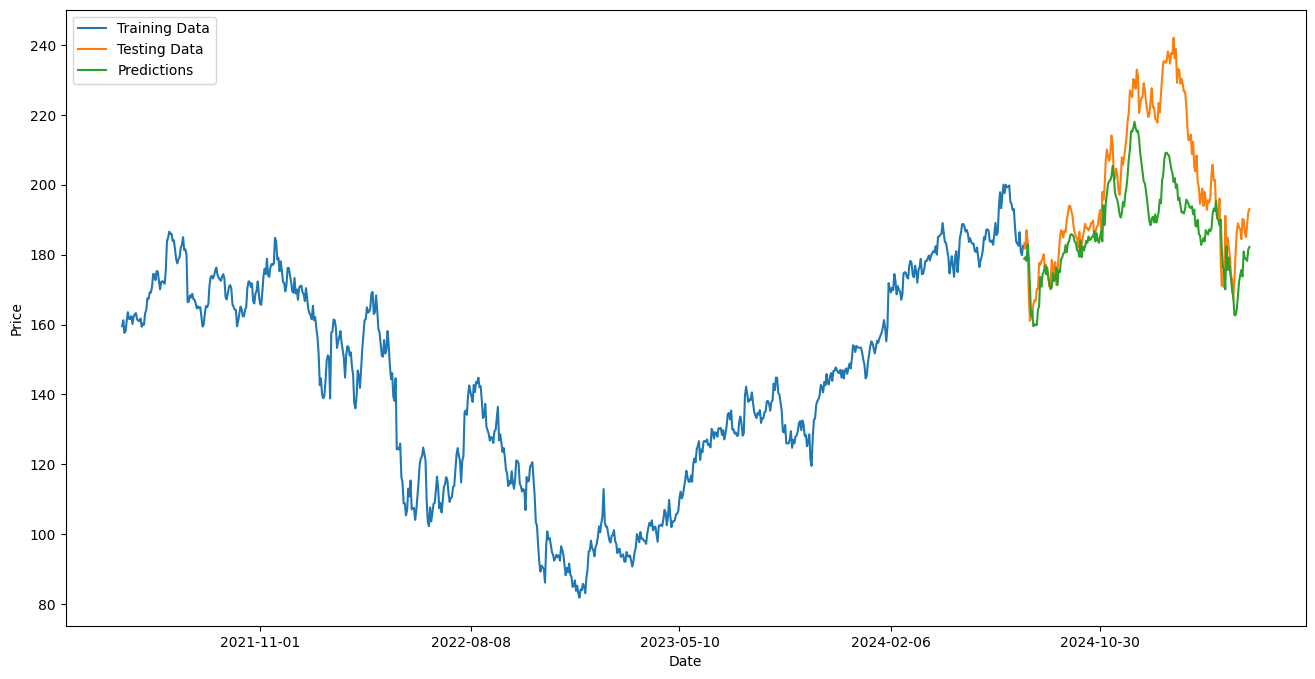

In [ ]:
train4 = amzn_data[:amzn_len]
train4['Date'] = dates[:amzn_len]
testing4 = amzn_data[amzn_len:]
testing4['Date'] = dates[amzn_len:]
testing4['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train4['Date'],train4['Close'], label = "Training Data")
plt.plot(testing4['Date'],testing4['Close'], label = "Testing Data")
plt.plot(testing4['Date'], testing4['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [ ]:
testing4.head()

,Close,Close_Difference,compound,neg,pos,Date,Predictions
785,183.199997,0.699997,0.9481,0.006,0.046,2024-07-29,178.808155
786,181.710007,-1.48999,-0.3612,0.049,0.038,2024-07-30,179.243092
787,186.979996,5.269989,0.9911,0.043,0.152,2024-07-31,178.199064
788,184.070007,-2.909988,0.6482,0.052,0.052,2024-08-01,182.912672
789,167.899994,-16.170013,0.8316,0.054,0.072,2024-08-02,179.099562


# **Model with Close, Neg,  Pos and Closing Difference Squared**

In [ ]:
data.head()

,Unnamed: 0,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,article-title,neg,neu,pos,compound,Close_Difference,Closing_Difference_Square
0,0,2021-05-10,164.115997,164.149994,159.500000,159.524506,116772000,0.0,0.0,"""'Formula One great to develop electric vans, ...",0.000,0.923,0.077,0.8850,-5.05549,25.557979
1,1,2021-05-11,156.813995,161.899994,156.368500,161.195496,92396000,0.0,0.0,"""'Washington Post names Sally Buzbee first wom...",0.067,0.889,0.044,-0.7430,1.67099,2.792208
2,2,2021-05-12,159.250000,160.397003,156.654999,157.597000,98728000,0.0,0.0,"""'Sonos boosts sales outlook despite global ch...",0.065,0.829,0.106,0.8449,-3.598495,12.94917
3,3,2021-05-13,159.273499,160.192001,156.649994,158.073502,67018000,0.0,0.0,"""'Amazon seeks renewable power for Japan data ...",0.017,0.855,0.128,0.9501,0.476501,0.227054
4,4,2021-05-14,159.278000,161.442993,159.149994,161.145004,66500000,0.0,0.0,"""'Less than 3% of U.S. small businesses could ...",0.014,0.914,0.072,0.9008,3.071503,9.434129


In [ ]:
data['Closing_Difference_Square'] = data['Close_Difference'] ** 2
amzn_data = data[['Close','neg','pos','Closing_Difference_Square']]
amzn_data.head()

,Close,neg,pos,Closing_Difference_Square
0,159.524506,0.000,0.077,25.557979
1,161.195496,0.067,0.044,2.792208
2,157.597000,0.065,0.106,12.94917
3,158.073502,0.017,0.128,0.227054
4,161.145004,0.014,0.072,9.434129


In [ ]:
amzn_data_array = amzn_data.values
print(amzn_data_array)

[[159.52450561523438 0.0 0.077 25.5579791401]
 [161.19549560546875 0.067 0.044 np.float64(2.7922075474634767)]
 [157.5970001220703 0.065 0.106 np.float64(12.949169744038954)]
 ...
 [188.7100067138672 0.036 0.033 np.float64(13.69009033217984)]
 [192.0800018310547 0.02 0.078 np.float64(11.356867089867592)]
 [193.0599975585937 0.081 0.035 np.float64(0.960391625994705)]]


In [ ]:
amzn_len = int(len(amzn_data_array) *0.8)
print(amzn_len)

785


In [ ]:
training_data = amzn_data_array[0:amzn_len]
print(training_data)
print('\n')
print(type(training_data))

[[159.52450561523438 0.0 0.077 25.5579791401]
 [161.19549560546875 0.067 0.044 np.float64(2.7922075474634767)]
 [157.5970001220703 0.065 0.106 np.float64(12.949169744038954)]
 ...
 [180.8300018310547 0.037 0.072 np.float64(31.136420434572713)]
 [179.85000610351562 0.039 0.06 np.float64(0.9603916259948164)]
 [182.5 0.007 0.057 np.float64(7.02246765140444)]]


<class 'numpy.ndarray'>


In [ ]:
x_scaler = MinMaxScaler(feature_range=(0,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[0.65750978 0.         0.1974359  0.06192886]
 [0.67164914 0.26070039 0.11282051 0.00676572]
 [0.64119987 0.25291829 0.27179487 0.03137679]
 ...
 [0.83778983 0.14396887 0.18461538 0.07544583]
 [0.82949743 0.15175097 0.15384615 0.0023271 ]
 [0.8519208  0.02723735 0.14615385 0.01701595]]


(785, 4)


In [ ]:
test = amzn_data_array[amzn_len:]
print(test.shape)

(197, 4)


In [ ]:
test_inputs = amzn_data_array[len(amzn_data) - len(test) - days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 4)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (257, 4)
Test inputs with a reshape : (257, 4)
Test inputs after transformed : (257, 4)


In [ ]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))

These values are smaller than the 60 day minimum
<class 'list'>
<class 'list'>


In [ ]:
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(725, 60, 4)
(725, 1)


In [ ]:
X_test = []
y_test = amzn_data_array[amzn_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],4))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(725, 60, 4)
725
60


In [ ]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],4))
print(X_test.shape)

(197, 60, 4)
(197, 60, 4)


In [ ]:
!pip install -q tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.2 MB/s eta 0:00:00


In [ ]:
modelcpns = Sequential()
modelcpns.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 4), activation='tanh'))
modelcpns.add(Dropout(0.2))
modelcpns.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
modelcpns.add(Dropout(0.2))
modelcpns.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
modelcpns.add(Dropout(0.2))
modelcpns.add(LSTM(units = 100, activation='tanh'))
modelcpns.add(Dropout(0.2))
modelcpns.add(Dense(units=1))
modelcpns.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
modelcpns.summary()

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
history5 = modelcpns.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.1047 - mae: 0.2446
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0131 - mae: 0.0881
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0086 - mae: 0.0732
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0084 - mae: 0.0716
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0083 - mae: 0.0715
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0072 - mae: 0.0661
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0064 - mae: 0.0617
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0063 - mae: 0.0602
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0060 - mae: 0.0597
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0060 - mae: 0.0602
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0061 - mae: 0.0607
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0066 - mae: 0.0639
Epoch 13/300
23/23 ━━━━━━

Text(0, 0.5, 'MAE')

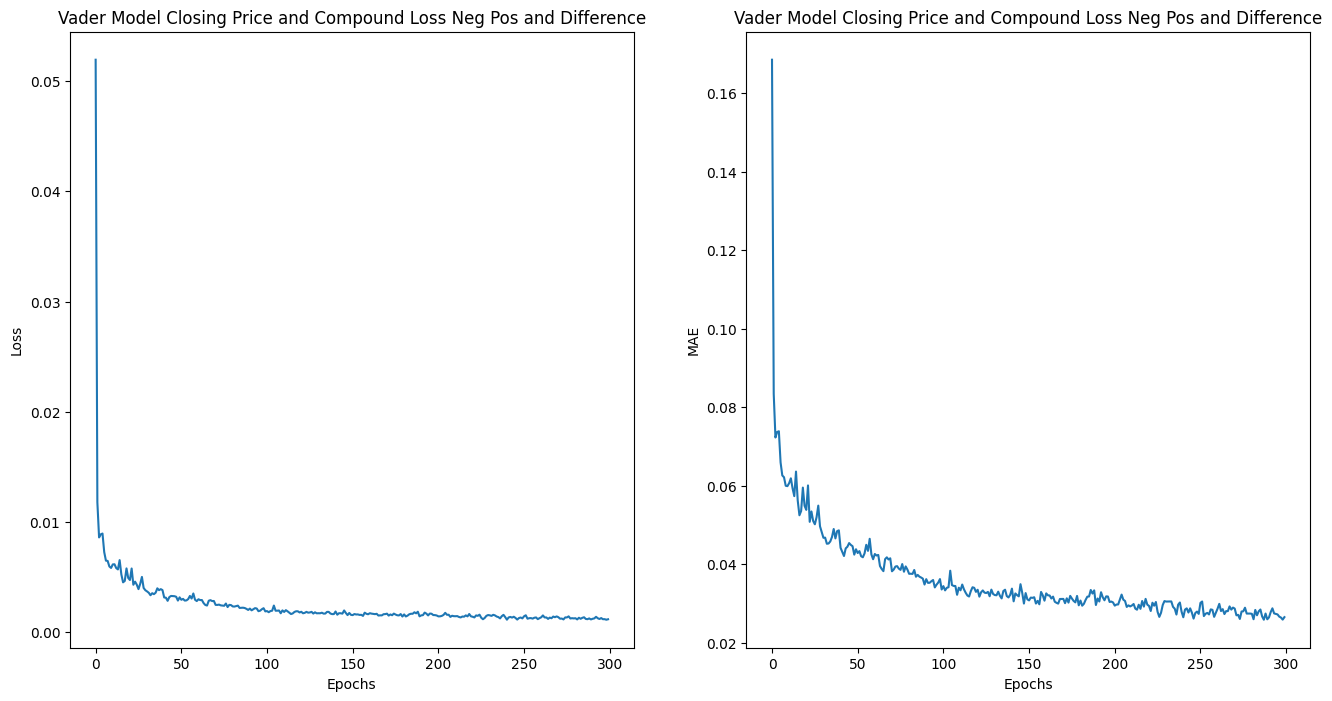

In [ ]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(history5.history['loss'], label = 'Training Loss')
plt.title("Vader Model Closing Price and Compound Loss Neg Pos and Difference")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(history5.history['mae'], label = 'Mean Absolute Error')
plt.title("Vader Model Closing Price and Compound Loss Neg Pos and Difference")
plt.xlabel("Epochs")
plt.ylabel("MAE")

In [ ]:
predictions = modelcpns.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 3))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
print(predictions_inverted)
print(predictions_concat.shape)
print(predictions.shape)
predictions = predictions_inverted[:, 0]
print(predictions)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
[[182.62882023   0.           0.           0.        ]
 [182.40504399   0.           0.           0.        ]
 [181.58109831   0.           0.           0.        ]
 [185.56725692   0.           0.           0.        ]
 [183.72525194   0.           0.           0.        ]
 [175.14991242   0.           0.           0.        ]
 [166.61362527   0.           0.           0.        ]
 [162.84685444   0.           0.           0.        ]
 [158.19767209   0.           0.           0.        ]
 [158.25556735   0.           0.           0.        ]
 [159.38669818   0.           0.           0.        ]
 [161.56900957   0.           0.           0.        ]
 [166.17048239   0.           0.           0.        ]
 [168.90094976   0.           0.           0.        ]
 [176.57547158   0.           0.           0.        ]
 [176.58451618   0.           0.           0.        ]
 [178.90291913   0.           0.           0.        ]
 [178.4467588    0.        

In [ ]:
rmse5 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse5)

6.465280055711265


<ipython-input-248-9430f385071f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train5['Date'] = dates[:amzn_len]
<ipython-input-248-9430f385071f>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing5['Date'] = dates[amzn_len:]
<ipython-input-248-9430f385071f>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

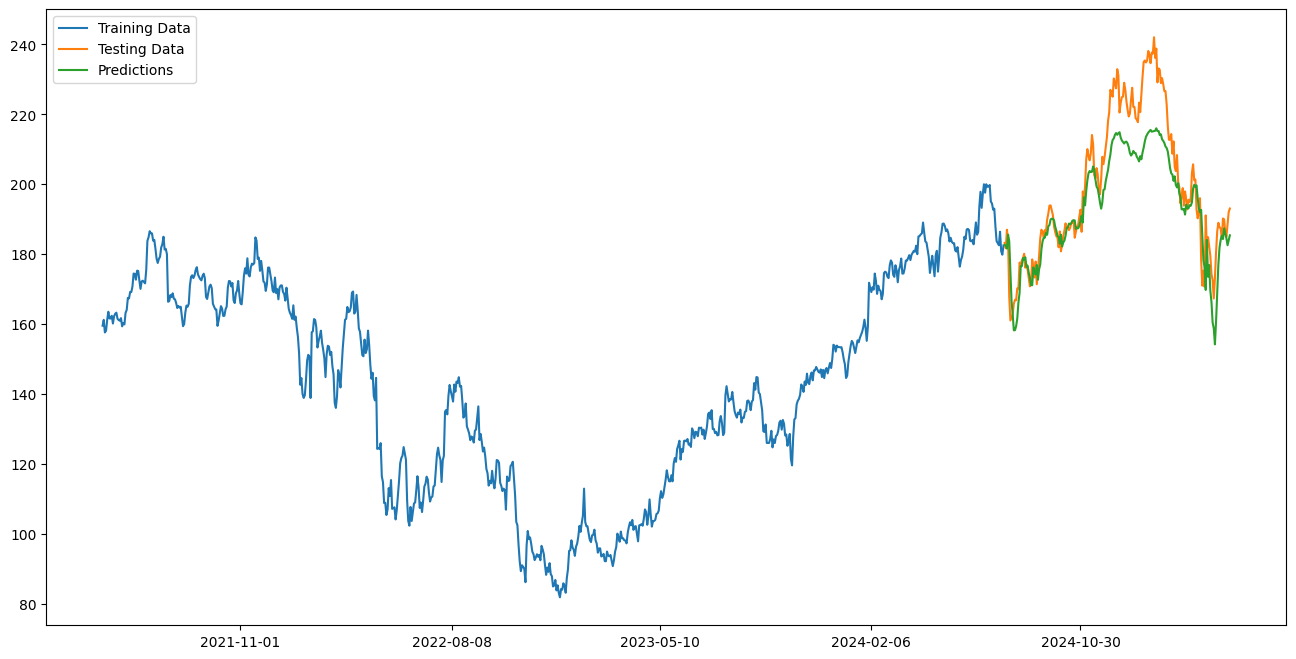

In [ ]:
train5 = amzn_data[:amzn_len]
train5['Date'] = dates[:amzn_len]
testing5 = amzn_data[amzn_len:]
testing5['Date'] = dates[amzn_len:]
testing5['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train5['Date'],train5['Close'], label = "Training Data")
plt.plot(testing5['Date'],testing5['Close'], label = "Testing Data")
plt.plot(testing5['Date'],testing5['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.legend()

In [ ]:
!pip install -q joblib

In [ ]:
PROJECT_FOLDER = "/content/gdrive/MyDrive/Colab Notebooks/Thesis/Models"
os.chdir(PROJECT_FOLDER)
print(os.getcwd())

/content/gdrive/MyDrive/Colab Notebooks/Thesis/Models


In [ ]:
import joblib
joblib.dump(model1,"DIFFERENCE_Model.pkl")
joblib.dump(model2, "VADER_CloseandDifferenceModel1.pkl")
joblib.dump(modelcpns, 'VADER_LAST_model_Difference.pkl')

['VADER_LAST_model_Difference.pkl']